<a href="https://colab.research.google.com/github/susmithagopireddy21-dot/Machine-Learning/blob/main/MLexp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
from pandas import read_csv
df=read_csv("placement_predict_50k Dataset.csv")

In [ ]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus', 'IsAnomaly', 'Salary Package']
Categorical Features: ['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']


In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [ ]:
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                    StudentID  SGPA_Sem1  SGPA_Sem2  SGPA_Sem3  SGPA_Sem4  \
StudentID            1.000000  -0.004221  -0.004321  -0.003670  -0.002203   
SGPA_Sem1           -0.004221   1.000000   0.963951   0.963790   0.963600   
SGPA_Sem2           -0.004321   0.963951   1.000000   0.964915   0.964800   
SGPA_Sem3           -0.003670   0.963790   0.964915   1.000000   0.965753   
SGPA_Sem4           -0.002203   0.963600   0.964800   0.965753   1.000000   
SGPA_Sem5           -0.002920   0.963188   0.964754   0.965477   0.966570   
SGPA_Sem6           -0.002474   0.962474   0.964251   0.965877   0.966524   
SGPA_Sem7           -0.002470   0.961925   0.963900   0.965480   0.966349   
SGPA_Sem8           -0.003057   0.960640   0.962899   0.964778   0.966118   
CGPA                -0.002534   0.911463   0.912570   0.913174   0.913727   
AttendancePercent    0.000299   0.496737   0.506104   0.513868   0.521876   
Internships          0.002501   0.446370   0.455

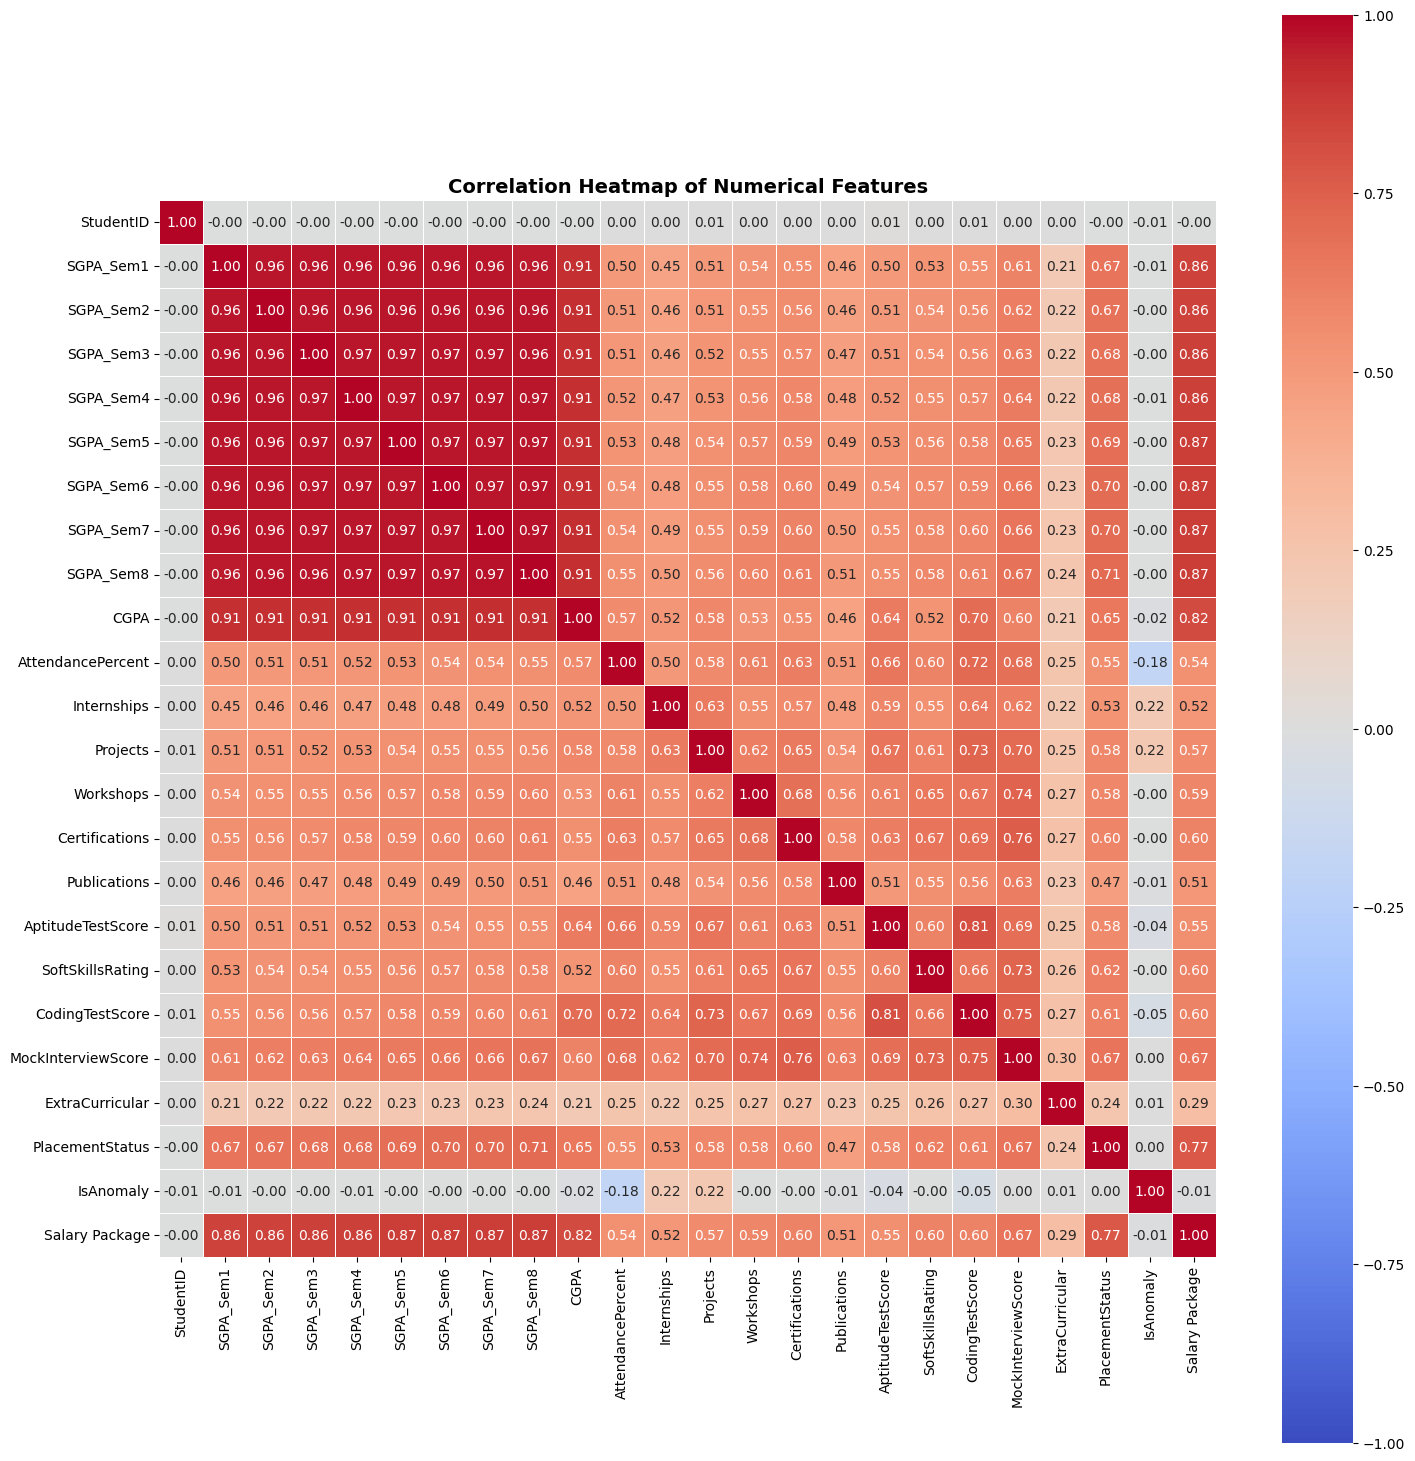

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [ ]:
import os
output_dir = r"C:\KLH\Subjects\ML(Y25)\PlacementPredict\reports"
os.makedirs(output_dir, exist_ok=True)
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: C:\KLH\Subjects\ML(Y25)\PlacementPredict\reports/correlation_heatmap.png


In [ ]:
target_col = "PlacementStatus"
if target_col in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)
        plt.tight_layout()
        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"
        boxplot_path = os.path.join(output_dir, boxplot_filename)
        plt.savefig(boxplot_path,    dpi=300,    bbox_inches="tight")
        plt.close()
        print(f"Exported boxplot to: {boxplot_path}")
    else:
        print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

        print("\nAll EDA tasks completed successfully!")



Exported boxplot to: C:\KLH\Subjects\ML(Y25)\PlacementPredict\reports/boxplot_StudentID_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\ML(Y25)\PlacementPredict\reports/boxplot_SGPA_Sem1_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\ML(Y25)\PlacementPredict\reports/boxplot_SGPA_Sem2_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\ML(Y25)\PlacementPredict\reports/boxplot_SGPA_Sem3_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\ML(Y25)\PlacementPredict\reports/boxplot_SGPA_Sem4_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\ML(Y25)\PlacementPredict\reports/boxplot_SGPA_Sem5_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\ML(Y25)\PlacementPredict\reports/boxplot_SGPA_Sem6_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\ML(Y25)\PlacementPredict\reports/boxplot_SGPA_Sem7_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\ML(Y25)\PlacementPredict\reports/boxplot_SGPA_Sem8_vs_PlacementStatus.png
E

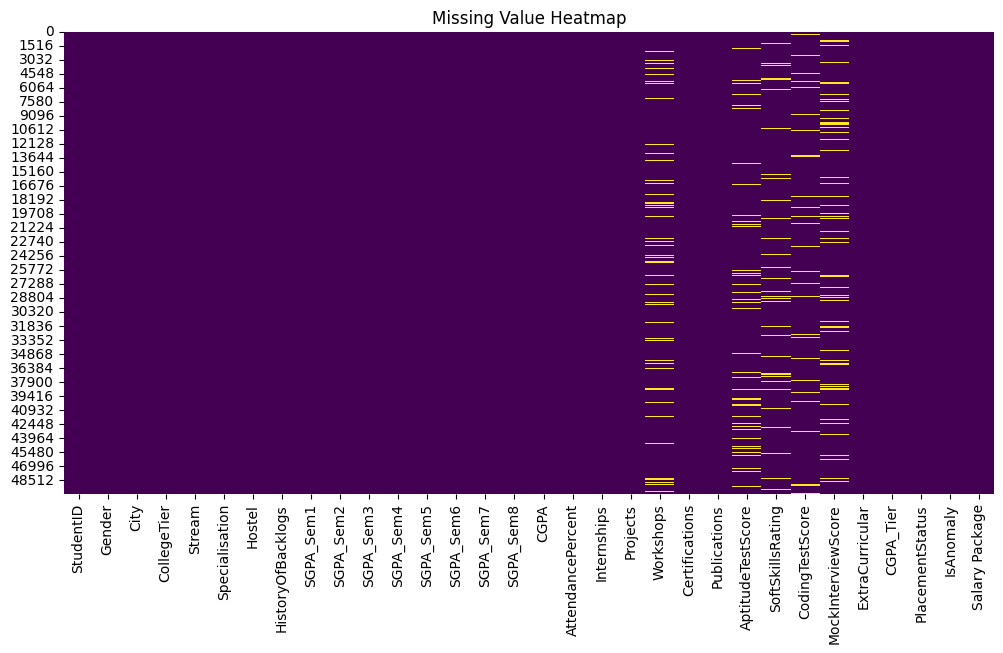

In [ ]:
import matplotlib.pyplot as plt
fig1=plt.figure(figsize=(12,6))
sns.heatmap(
         df.isnull(),
        cbar=False,
         cmap="viridis"
)
plt.title("Missing Value Heatmap")
plt.show()

In [ ]:
# Rename dataset columns to match mam's feature names

df = df.rename(columns={
    "AptitudeTestScore": "Aptitude_Test_Score",
    "CodingTestScore": "Coding_Skills",
    "SoftSkillsRating": "Communication_Skills",
    "HistoryOfBacklogs": "Backlogs"
})

# Age is NOT present in your dataset.
# Therefore, we cannot create the Age graph from this CSV.

In [ ]:
print(df.columns.tolist())

['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'Backlogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'Aptitude_Test_Score', 'Communication_Skills', 'Coding_Skills', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']


<Figure size 1500x800 with 0 Axes>

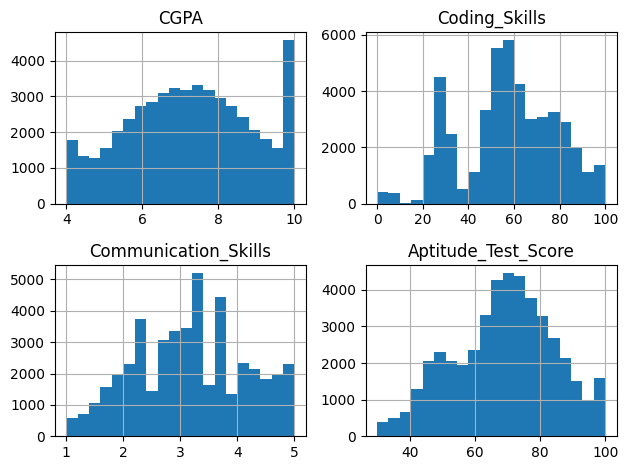

In [ ]:
# Rename columns to match mam's names

df = df.rename(columns={
    "CodingTestScore": "Coding_Skills",
    "SoftSkillsRating": "Communication_Skills",
    "AptitudeTestScore": "Aptitude_Test_Score",
    "HistoryOfBacklogs": "Backlogs"
})

features = ["CGPA", "Coding_Skills", "Communication_Skills",
            "Aptitude_Test_Score", "Backlogs"]

fig2 = plt.figure(figsize=(15,8))

df[features].hist(
    bins=20
)

plt.tight_layout()

plt.show()

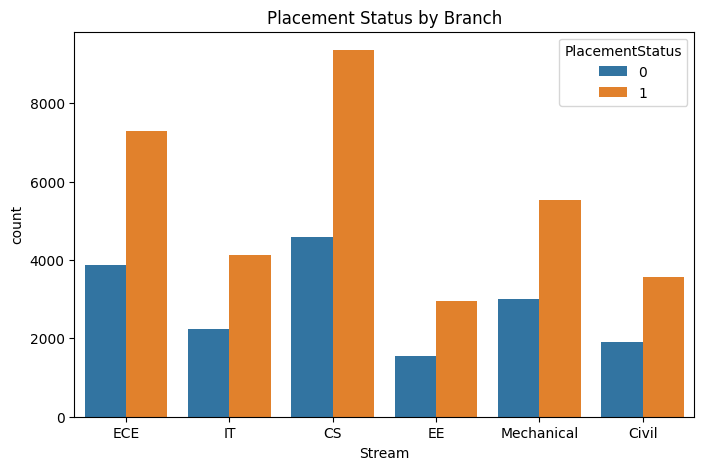

In [ ]:
# Placement rate by branch

fig3 = plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Stream",
    hue="PlacementStatus"
)

plt.title("Placement Status by Branch")

plt.show()

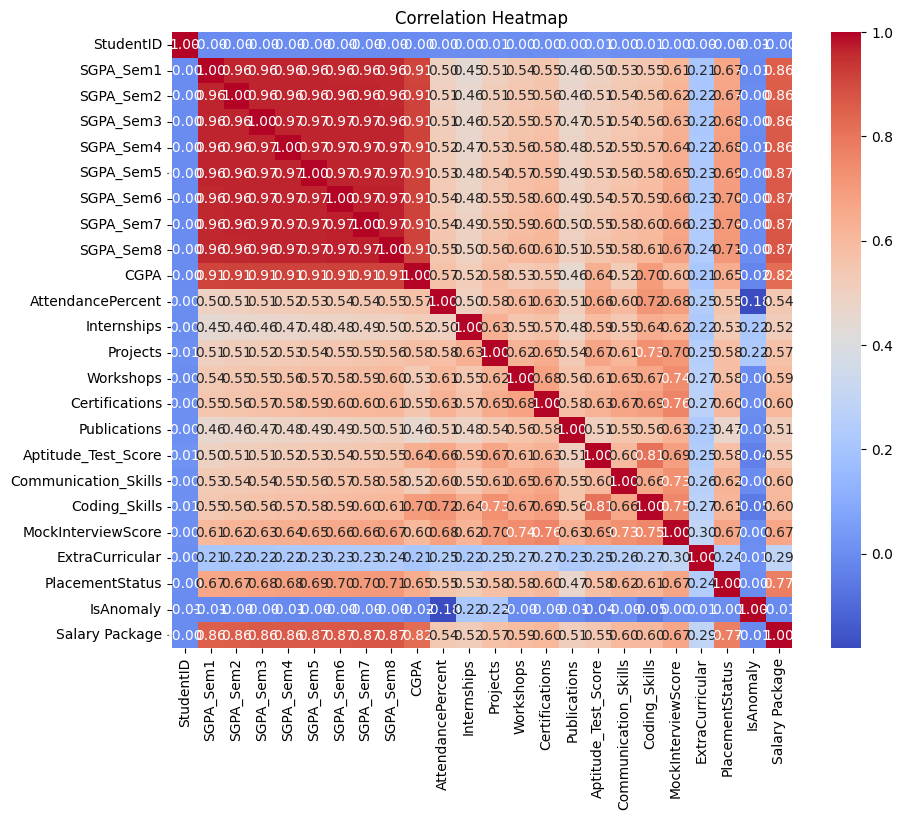

In [ ]:
#Corelation Heatmap

fig5= plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()